In [1]:
import torch
import numpy as np

# reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [2]:
from google.colab import drive

# mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import json

In [4]:
# dominant class sample count
TARGET_COUNT = 1834
SPLIT_PATH = "/content/split_seed42_aug_80_20_balanced.json"
MODEL_PATH = "/content/ckpt_ep20.pt"
OUTPUT_DIR = Path("generated_PET_samples_up8")

# load split info
with open(SPLIT_PATH, 'r') as f:
    split_info = json.load(f)

# check training class counts
class_counts = split_info['class_counts']
print("Training split:")
for cls, counts in class_counts.items():
    print(f"  {cls}: total={counts['total']}, train={counts['train']}, test={counts['test']}")

# classes to generat samples
classes_to_generate = {
    'B': TARGET_COUNT - class_counts['B']['train'],
    'G': TARGET_COUNT - class_counts['G']['train'],
}

print("\nSamples to generate for balancing:")
for cls, count in classes_to_generate.items():
    print(f"  {cls}: {count} sequences")

Training split:
  A: total=2292, train=1834, test=458
  B: total=126, train=101, test=25
  G: total=484, train=387, test=97

Samples to generate for balancing:
  B: 1733 sequences
  G: 1447 sequences


In [5]:
# load the trained model configuration and weights
checkpoint = torch.load(MODEL_PATH, map_location=device)
CONFIG = checkpoint['config']

print("Model Configuration:")
print(f"  Image size: {CONFIG['image_size']}×{CONFIG['image_size']}")
print(f"  Sequence length: {CONFIG['seq_length']} frames")
print(f"  Classes: {CONFIG['classes']}")
print(f"  Channels: {CONFIG['channels']}")
print(f"  Timesteps: {CONFIG['timesteps']}")
print(f"  Prediction type: {CONFIG['prediction_type']}")

# class to index mapping
class_to_idx = {c: i for i, c in enumerate(CONFIG['classes'])}
print(f"\nClass mapping: {class_to_idx}")

Model Configuration:
  Image size: 128×128
  Sequence length: 8 frames
  Classes: ['A', 'B', 'G']
  Channels: (64, 128, 256)
  Timesteps: 1000
  Prediction type: v_prediction

Class mapping: {'A': 0, 'B': 1, 'G': 2}


In [6]:
from diffusers import UNet2DModel, DDPMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [7]:
# model architecture

model = UNet2DModel(
    sample_size=CONFIG['image_size'],
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=CONFIG['channels'],

    # encoder
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),

    # decoder
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),

    # class conditioning
    class_embed_type="timestep",
    num_class_embeds=len(CONFIG['classes']),
).to(device)

# DDPM Scheduler
scheduler = DDPMScheduler(
    num_train_timesteps=CONFIG['timesteps'],
    beta_schedule="squaredcos_cap_v2",
    prediction_type=CONFIG['prediction_type']
)

# load EMA weights
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = float(decay)
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.detach().clone()

    @torch.no_grad()
    def copy_to(self, model):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if name in self.shadow:
                param.data.copy_(self.shadow[name].data)

# load model weights
model.load_state_dict(checkpoint['model'])
print("Model weights loaded")

# load EMA weights if available
ema = EMA(model, decay=CONFIG.get('ema_decay', 0.999))
if 'ema' in checkpoint and isinstance(checkpoint['ema'], dict):
    ema.shadow = checkpoint['ema']
    print("EMA weights loaded")
else:
    print("No EMA weights found, using model weights")

# model stats
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

Model weights loaded
EMA weights loaded
Total parameters: 14.82M


In [8]:
from torch.amp import autocast

In [9]:
# generation function (batch generation)
def generate_samples(model, scheduler, ema, class_idx, n_samples, n_frames=8,
                     batch_size=16, inference_steps=1000, use_ema=True):
    """
    Generate synthetic samples using EMA weights.

    Args:
        model: UNet2DModel
        scheduler: DDPMScheduler
        ema: EMA wrapper
        class_idx: int, class index
        n_samples: int, number of sequences to generate
        n_frames: int, frames per sequence (default: 8)
        batch_size: int, batch size for generation
        inference_steps: int, number of DDPM sampling steps
        use_ema: bool, whether to use EMA weights

    Returns:
        numpy array of shape (n_samples, n_frames, H, W) in [0, 1] range
    """
    model.eval()

    # apply EMA weights for better sample quality
    restore_state = None
    if use_ema:
        restore_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        ema.copy_to(model)

    all_samples = []
    remaining = n_samples

    with torch.no_grad():
        pbar = tqdm(total=n_samples, desc=f"Generating class {CONFIG['classes'][class_idx]}")

        while remaining > 0:
            current_batch = min(batch_size, remaining)
            total_frames = current_batch * n_frames

            # start from random noise
            x = torch.randn(total_frames, 1, CONFIG['image_size'], CONFIG['image_size'], device=device)
            labels = torch.full((total_frames,), class_idx, device=device, dtype=torch.long)

            # set sampling schedule
            scheduler.set_timesteps(inference_steps)

            # reverse diffusion process
            for t in scheduler.timesteps:
                ts = torch.full((total_frames,), t, device=device, dtype=torch.long)
                with autocast(device_type=device.type, enabled=CONFIG.get('use_fp16', True)):
                    pred = model(x, ts, class_labels=labels).sample
                x = scheduler.step(pred, t, x).prev_sample

            # reshape to (batch, n_frames, 1, H, W) and convert to numpy
            samples = x.view(current_batch, n_frames, 1, CONFIG['image_size'], CONFIG['image_size'])

            # convert from [-1, 1] to [0, 1] and remove channel dim -> (batch, n_frames, H, W)
            samples = ((samples + 1) / 2).clamp(0, 1).squeeze(2).cpu().numpy()

            all_samples.append(samples)
            remaining -= current_batch
            pbar.update(current_batch)

        pbar.close()

    # restore original weights if EMA was used
    if use_ema and restore_state is not None:
        model.load_state_dict(restore_state)

    # clear GPU cache
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return np.concatenate(all_samples, axis=0)  # (n_samples, n_frames, H, W)

In [10]:
# Create output directories
for cls in classes_to_generate.keys():
    output_path = OUTPUT_DIR / cls
    output_path.mkdir(parents=True, exist_ok=True)

# Verify directories are ready
print(f"\nOutput structure:")
print(f"  {OUTPUT_DIR}/")
for cls in classes_to_generate.keys():
    print(f"    {cls}/")


Output structure:
  generated_PET_samples_up8/
    B/
    G/


In [11]:
import gc

In [12]:
if torch.cuda.is_available():

    # clear cached memory
    torch.cuda.empty_cache()
    gc.collect()

    # check current GPU memory usage
    allocated = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    available = total - allocated

    print(f"Allocated: {allocated:.2f} GB")
    print(f"Available: {available:.2f} GB")

else:
    print("No GPU detected — training will run on CPU")

Allocated: 0.30 GB
Available: 84.86 GB


In [13]:
from tqdm.auto import tqdm

In [14]:
BATCH_SIZE = 100

# denoising steps
INFERENCE_STEPS = 50

generation_summary = {}

for cls, n_samples in classes_to_generate.items():

    class_idx = class_to_idx[cls]
    output_path = OUTPUT_DIR / cls

    # generate all samples
    samples = generate_samples(
        model=model,
        scheduler=scheduler,
        ema=ema,
        class_idx=class_idx,
        n_samples=n_samples,
        n_frames=CONFIG['seq_length'],
        batch_size=BATCH_SIZE,
        inference_steps=INFERENCE_STEPS,
        use_ema=True
    )

    print(f"\nGenerated samples shape: {samples.shape}")
    print(f"Sample range: [{samples.min():.4f}, {samples.max():.4f}]")

    # save each sample as a separate .npy file
    saved_files = []

    for i in tqdm(range(n_samples), desc=f"Saving {cls} samples"):

        # naming convention: BGen0001, BGen0002, etc.
        filename = f"{cls}Gen{i+1:04d}.npy"
        filepath = output_path / filename

        # save as numpy array (shape: 8, 128, 128) in [0, 1] range
        np.save(filepath, samples[i].astype(np.float32))
        saved_files.append(filename)

    generation_summary[cls] = {
        'samples_generated': n_samples,
        'existing_train_samples': class_counts[cls]['train'],
        'total_after_augmentation': n_samples + class_counts[cls]['train'],
        'target': TARGET_COUNT,
        'output_directory': str(output_path),
        'sample_shape': list(samples[0].shape),
        'files_saved': len(saved_files)
    }

    print(f"\nSaved samples to {output_path}")
    print(f"\nSaved {len(saved_files)} files for class {cls}")

Generating class B:   0%|          | 0/1733 [00:00<?, ?it/s]


Generated samples shape: (1733, 8, 128, 128)
Sample range: [0.0000, 1.0000]


Saving B samples:   0%|          | 0/1733 [00:00<?, ?it/s]


Saved samples to generated_PET_samples_up8/B

Saved 1733 files for class B


Generating class G:   0%|          | 0/1447 [00:00<?, ?it/s]


Generated samples shape: (1447, 8, 128, 128)
Sample range: [0.0000, 1.0000]


Saving G samples:   0%|          | 0/1447 [00:00<?, ?it/s]


Saved samples to generated_PET_samples_up8/G

Saved 1447 files for class G


In [15]:
for cls, summary in generation_summary.items():
    print(f"\nClass {cls}:")
    print(f"  Existing train samples: {summary['existing_train_samples']}")
    print(f"  Generated samples: {summary['samples_generated']}")
    print(f"  Total after augmentation: {summary['total_after_augmentation']}")

# save generation summary to JSON
summary_path = OUTPUT_DIR / "generation_summary.json"
with open(summary_path, 'w') as f:
    json.dump({
        'generation_config': {
            'model_path': MODEL_PATH,
            'split_path': SPLIT_PATH,
            'batch_size': BATCH_SIZE,
            'inference_steps': INFERENCE_STEPS,
            'sequence_length': CONFIG['seq_length'],
            'image_size': CONFIG['image_size'],
            'target_count': TARGET_COUNT,
        },
        'class_summary': generation_summary
    }, f, indent=2)


Class B:
  Existing train samples: 101
  Generated samples: 1733
  Total after augmentation: 1834

Class G:
  Existing train samples: 387
  Generated samples: 1447
  Total after augmentation: 1834


In [16]:
import shutil

In [17]:
DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/Generated_PET_Samples_up8')

# create the directory if it doesn't exist
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# move the 'generated' folder to Google Drive
if OUTPUT_DIR.exists():
    for item in OUTPUT_DIR.iterdir():
        destination_path = DRIVE_OUTPUT_DIR / item.name
        if item.is_dir():
            shutil.move(str(item), str(destination_path))
        else:
            shutil.move(str(item), str(destination_path))
    print(f"Moved all generated files from '{OUTPUT_DIR}' to '{DRIVE_OUTPUT_DIR}'")
else:
    print(f"Source directory '{OUTPUT_DIR}' does not exist. No files to move.")


Moved all generated files from 'generated_PET_samples_up8' to '/content/drive/MyDrive/Generated_PET_Samples_up8'


In [18]:
import matplotlib.pyplot as plt

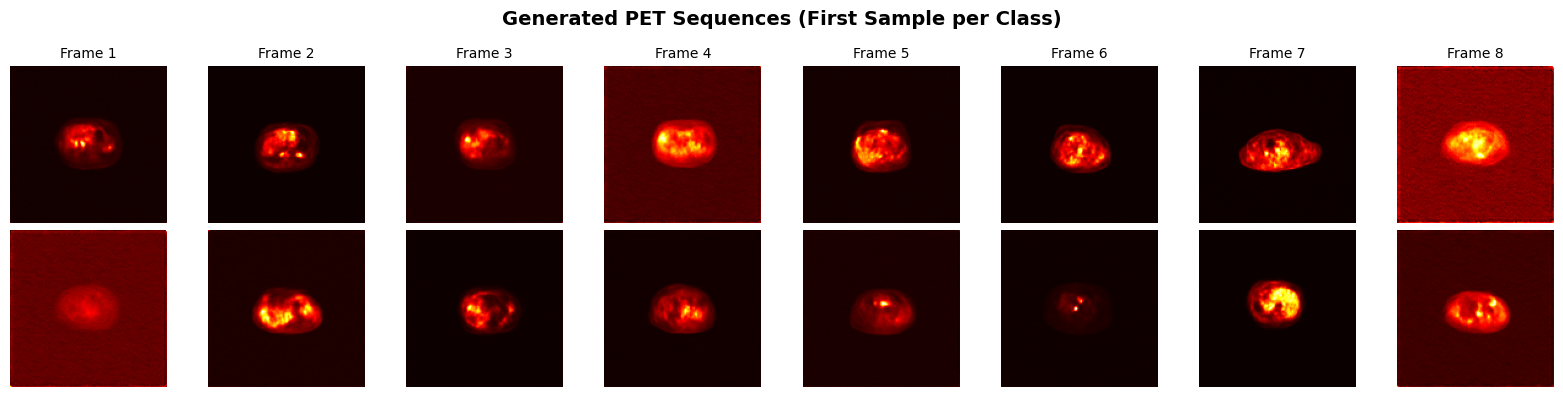


Visualization saved to: generated_PET_samples_up8/sample_visualization.png


In [19]:
# visualize first generated sample of each class
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for row_idx, cls in enumerate(classes_to_generate.keys()):
    output_path = DRIVE_OUTPUT_DIR / cls
    sample_files = sorted(list(output_path.glob(f"{cls}Gen*.npy")))

    if sample_files:

        # load first generated sample
        sample = np.load(sample_files[0])  # Shape: (8, 128, 128)

        # display all 8 frames
        for frame_idx in range(8):
            axes[row_idx, frame_idx].imshow(sample[frame_idx], cmap='hot')
            axes[row_idx, frame_idx].axis('off')
            if frame_idx == 0:
                axes[row_idx, frame_idx].set_ylabel(f'Class {cls}', fontsize=12, fontweight='bold')
            if row_idx == 0:
                axes[row_idx, frame_idx].set_title(f'Frame {frame_idx+1}', fontsize=10)

plt.suptitle('Generated PET Sequences (First Sample per Class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {OUTPUT_DIR / 'sample_visualization.png'}")

In [20]:
final_counts = {}
for cls in ['A', 'B', 'G']:
    train_count = class_counts[cls]['train']

    if cls in classes_to_generate:
        output_path = DRIVE_OUTPUT_DIR / cls
        generated_count = len(list(output_path.glob(f"{cls}Gen*.npy")))
    else:
        generated_count = 0

    total = train_count + generated_count
    final_counts[cls] = {
        'train': train_count,
        'generated': generated_count,
        'total': total
    }

print("\n{:<10} {:>15} {:>15} {:>15}".format("Class", "Original", "Generated", "Total"))
print("-" * 60)
for cls, counts in final_counts.items():
    print("{:<10} {:>15} {:>15} {:>15}".format(
        cls, counts['train'], counts['generated'], counts['total']
    ))
print("-" * 60)
print("{:<10} {:>15} {:>15} {:>15}".format(
    "TOTAL",
    sum(c['train'] for c in final_counts.values()),
    sum(c['generated'] for c in final_counts.values()),
    sum(c['total'] for c in final_counts.values())
))


Class             Original       Generated           Total
------------------------------------------------------------
A                     1834               0            1834
B                      101            1733            1834
G                      387            1447            1834
------------------------------------------------------------
TOTAL                 2322            3180            5502
